# HW2 313551170

## 1.

In [6]:
import librosa
import mirdata
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import IPython.display as ipd

In [7]:
tinysol_dataset = mirdata.initialize("tinysol")
tinysol_dataset.download()
tinysol_metadata = tinysol_dataset._metadata

INFO: Downloading ['audio', 'annotations', 'index']. Index is being stored in C:\Users\WilsonW\anaconda3\envs\mir_env\Lib\site-packages\mirdata\datasets\indexes, and the rest of files in /tmp\mir_datasets\tinysol
INFO: [audio] downloading TinySOL.tar.gz
INFO: /tmp\mir_datasets\tinysol\audio\TinySOL.tar.gz already exists and will not be downloaded. Rerun with force_overwrite=True to delete this file and force the download.
INFO: [annotations] downloading TinySOL_metadata.csv
INFO: /tmp\mir_datasets\tinysol\annotation\TinySOL_metadata.csv already exists and will not be downloaded. Rerun with force_overwrite=True to delete this file and force the download.
INFO: [index] downloading tinysol_index_6.0.json
488kB [00:02, 218kB/s]                             


In [38]:
import pandas as pd

# 將 dictionary 轉為 DataFrame
meta_records = []

for track_id, metadata in tinysol_metadata.items():
    meta_records.append({
        'track_id': track_id,
        'fold': metadata['Fold'],
        'instrument': metadata['Instrument (abbr.)'],
        'pitch': metadata['Pitch']
    })

metadata_df = pd.DataFrame(meta_records)

In [42]:
for i in metadata_df.track_id:
    print(i)

BTb-ord-F#1-pp-N-N
BTb-ord-G1-pp-N-R100u
BTb-ord-G#1-pp-N-T16u
BTb-ord-A1-pp-N-T23d
BTb-ord-A#1-pp-N-N
BTb-ord-B1-pp-N-N
BTb-ord-C2-pp-N-T13d
BTb-ord-C#2-pp-N-N
BTb-ord-D2-pp-N-T18u
BTb-ord-D#2-pp-N-T11u
BTb-ord-E2-pp-N-T25u
BTb-ord-F2-pp-N-T25u_R100u
BTb-ord-F#2-pp-N-T14u
BTb-ord-G2-pp-N-N
BTb-ord-G#2-pp-N-T16u
BTb-ord-A2-pp-N-T15u
BTb-ord-A#2-pp-N-N
BTb-ord-B2-pp-N-T11d
BTb-ord-C3-pp-N-T11d
BTb-ord-C#3-pp-N-N
BTb-ord-D3-pp-N-N
BTb-ord-D#3-pp-N-N
BTb-ord-E3-pp-N-N
BTb-ord-F3-pp-N-N
BTb-ord-F#3-pp-N-N
BTb-ord-G3-pp-N-T14d
BTb-ord-G#3-pp-N-N
BTb-ord-A3-pp-N-N
BTb-ord-A#3-pp-N-T13d
BTb-ord-B3-pp-N-T14d
BTb-ord-C4-pp-N-N
BTb-ord-C#4-pp-N-N
BTb-ord-D4-pp-N-N
BTb-ord-D#4-pp-N-N
BTb-ord-E4-pp-N-N
BTb-ord-F4-pp-N-N
BTb-ord-F#1-mf-N-T18u
BTb-ord-G1-mf-N-N
BTb-ord-G#1-mf-N-T18u
BTb-ord-A1-mf-N-T33u
BTb-ord-A#1-mf-N-N
BTb-ord-B1-mf-N-T16u
BTb-ord-C2-mf-N-T23u
BTb-ord-C#2-mf-N-N
BTb-ord-D2-mf-N-T15u
BTb-ord-D#2-mf-N-T34u
BTb-ord-E2-mf-N-T27u
BTb-ord-F2-mf-N-T24u
BTb-ord-F#2-mf-N-T19u
BTb-ord-G2-m

### 1.a.

| 部分 | 說明 |
|:----|:----|
| **Hn** | 樂器縮寫，代表 **French Horn** |
| **ord** | 表示使用的是 **ordinario** |
| **C4** | 音高，**中央C**，頻率約為 261.63 Hz |
| **pp** | 音量強度，**pianissimo** |
| **N** | INSTANCE 欄位，代表無額外資訊（Not Applicable） |
| **N** | MISC 欄位，代表原音錄製（Natural），即沒有經過數位變調或音高修正 |

### 1.b.

In [8]:
def PlotSpectrogram(ax, title, S_db, sr, y_axis):
    img = librosa.display.specshow(S_db, x_axis='time', y_axis=y_axis, sr=sr, fmax=8000, ax=ax)
    plt.colorbar(img, ax=ax, format='%+2.0f dB')
    ax.set(title=title)

In [9]:
tpc_id = 'TpC-ord-C6-mf-N-T11u'
btb_id = 'BTb-ord-F#1-mf-N-T18u'
tpc_track = tinysol_dataset.track(tpc_id)
btb_track = tinysol_dataset.track(btb_id)

In [10]:
ipd.Audio(tpc_track.audio[0], rate=tpc_track.audio[1])

In [11]:
ipd.Audio(btb_track.audio[0], rate=btb_track.audio[1])

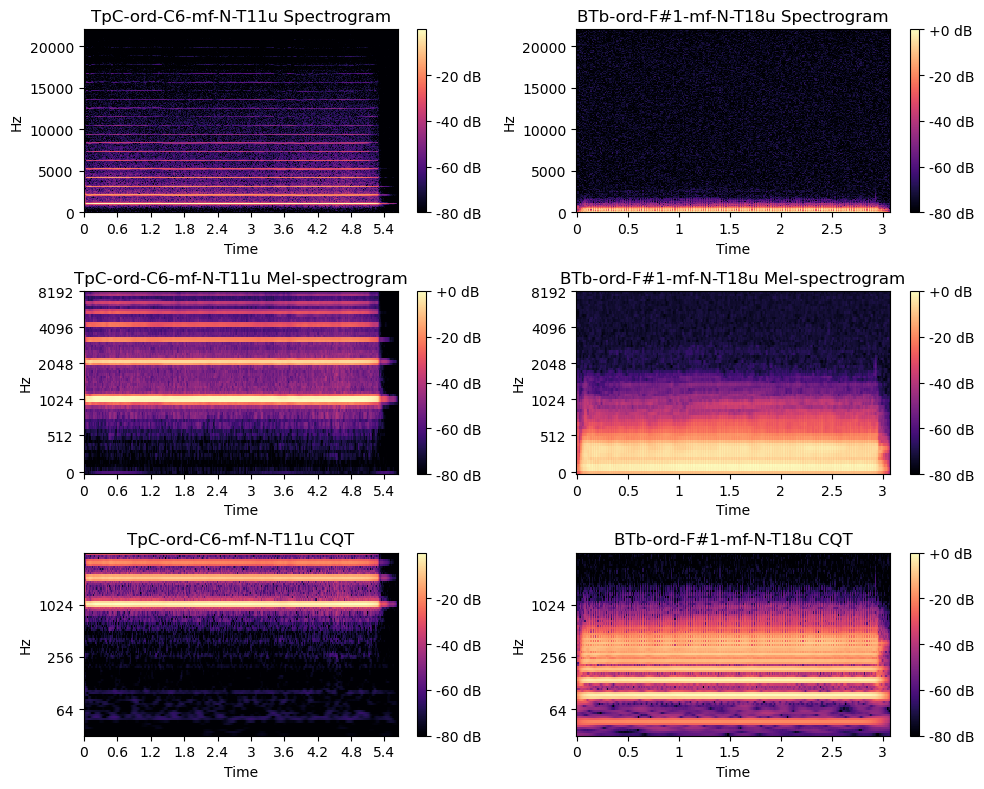

In [12]:
def PlotMultiSpectrogram(track_id, track, axs, col, window_size=1024, hop_size=512):
    audio, sr = track.audio
    spec = librosa.amplitude_to_db(np.abs(librosa.stft(audio, n_fft=window_size, hop_length=hop_size)), ref=np.max)
    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=64, fmax=8000), ref=np.max)
    cqt = librosa.amplitude_to_db(np.abs(librosa.cqt(audio, sr=sr)), ref=np.max)

    PlotSpectrogram(axs[0, col], track_id + ' Spectrogram', spec, sr, 'linear')
    PlotSpectrogram(axs[1, col], track_id + ' Mel-spectrogram', mel, sr, 'mel')
    PlotSpectrogram(axs[2, col], track_id + ' CQT', cqt, sr, 'cqt_hz')


fig, axs = plt.subplots(3, 2, figsize=(10, 8))

PlotMultiSpectrogram(tpc_id, tpc_track, axs, 0)
PlotMultiSpectrogram(btb_id, btb_track, axs, 1)

plt.tight_layout()
plt.show()

這兩個音檔的樂器分別為 Trumpet in C 及 Bass Tuba ， Trumpet in C 的音域較高而 Bass Tuba 的音域較低，這點在圖中可以很明顯的看出來。  
Trumpet in C 的這個音檔會較為適合使用 Mel-spectrogram ，因為可以很明顯地看到基頻在哪裡，泛音也可以很清楚的看到。用 CQT 則太高頻的泛音就看不到；用 Spectrogram 則基頻不好分辨。  
Bass Tuba 的這個音檔會較為適合使用 CQT ，因為只有 CQT 可以看清楚頻率分布，其他方法都會糊在一起。  

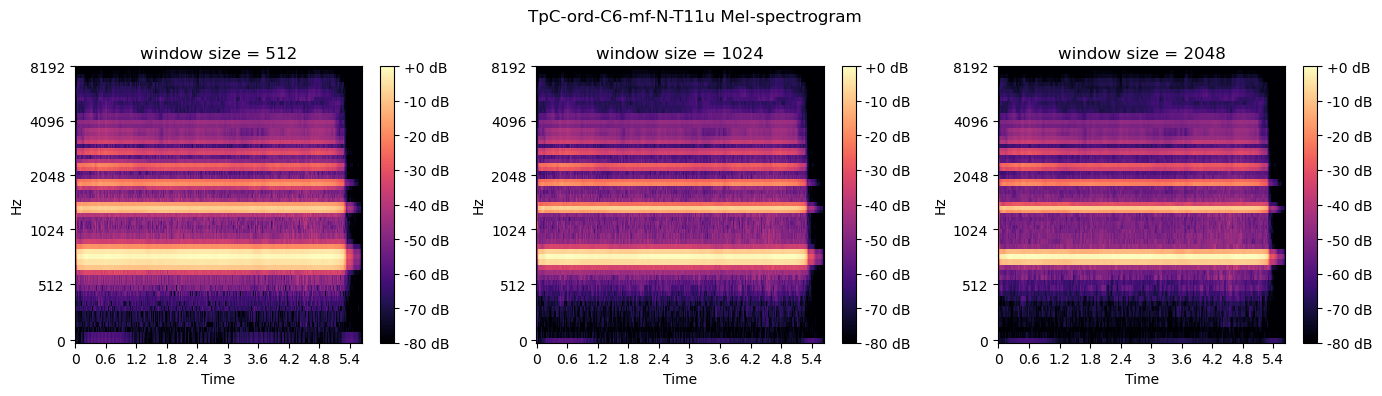

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
audio, sr = tpc_track.audio
mel0 = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=512, n_mels=64, fmax=sr//2), ref=np.max)
mel1 = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=1024, n_mels=64, fmax=sr//2), ref=np.max)
mel2 = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=2048, n_mels=64, fmax=sr//2), ref=np.max)
PlotSpectrogram(axs[0], 'window size = 512', mel0, sr, 'mel')
PlotSpectrogram(axs[1], 'window size = 1024', mel1, sr, 'mel')
PlotSpectrogram(axs[2], 'window size = 2048', mel2, sr, 'mel')

plt.suptitle(tpc_id + ' Mel-spectrogram')
plt.tight_layout()
plt.show()

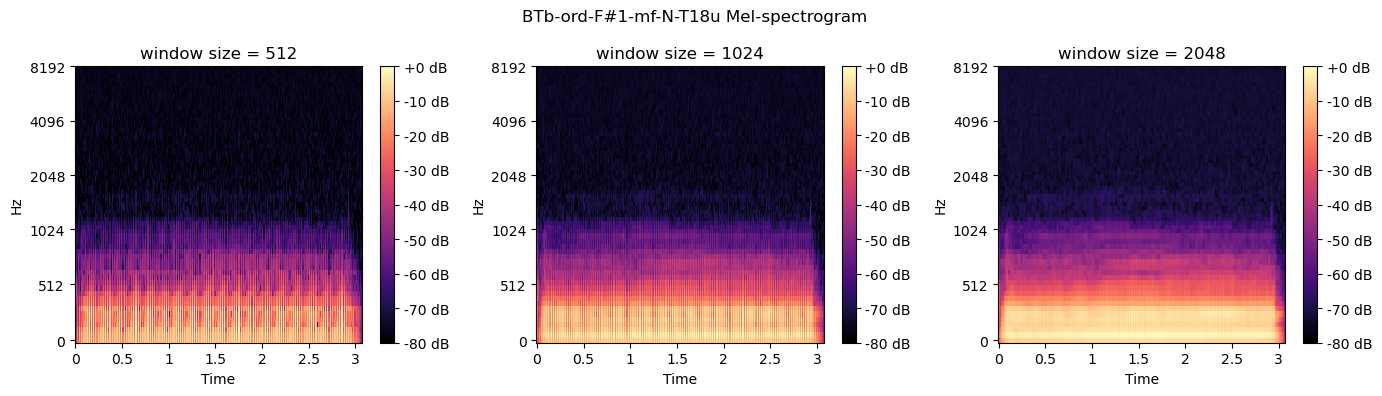

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
audio, sr = btb_track.audio
mel0 = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=512, n_mels=64, fmax=sr//2), ref=np.max)
mel1 = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=1024, n_mels=64, fmax=sr//2), ref=np.max)
mel2 = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=2048, n_mels=64, fmax=sr//2), ref=np.max)
PlotSpectrogram(axs[0], 'window size = 512', mel0, sr, 'mel')
PlotSpectrogram(axs[1], 'window size = 1024', mel1, sr, 'mel')
PlotSpectrogram(axs[2], 'window size = 2048', mel2, sr, 'mel')

plt.suptitle(btb_id + ' Mel-spectrogram')
plt.tight_layout()
plt.show()

因為這兩個音檔都是單一個音而已，沒有旋律變化，所以可以用較大的 window size ，在頻率的維度可以更看得清楚，在時間的維度上因為沒有旋律變化所以不需要分得很清楚。

### 1.c.

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, ConfusionMatrixDisplay,f1_score
from sklearn.svm import SVC
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import itertools

In [17]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues, figsize=(6, 6)):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix')
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.set_title(title)
    fig.colorbar(im)
    tick_marks = np.arange(len(classes))
    ax.set_xticks(tick_marks, classes, rotation=90)
    ax.set_yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')
    plt.show()

#### 1.c.a.

In [ ]:
spec_list = []
mel_list = []
cqt_list = []
instrument_list = []
# pitch_list = []

for track_id in tinysol_dataset.track_ids:

    track = tinysol_dataset.track(track_id)
    audio, sr = track.audio

    spec = librosa.amplitude_to_db(np.abs(librosa.stft(audio, n_fft=2048, hop_length=512)), ref=np.max)
    feat = np.mean(spec, axis=1)
    spec_list.append(feat)

    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=2048, n_mels=64, fmax=sr//2), ref=np.max)
    feat = np.mean(mel, axis=1)
    mel_list.append(feat)

    cqt = librosa.amplitude_to_db(np.abs(librosa.cqt(audio, sr=sr)), ref=np.max)
    feat = np.mean(cqt, axis=1)
    cqt_list.append(feat)

    instrument_list.append(track.instrument_full)
    # pitch_list.append(track.pitch)

spec_array = np.array(spec_list)
mel_array = np.array(mel_list)
cqt_array = np.array(cqt_list)
instrument_array = np.array(instrument_list)
# pitch_array = np.array(pitch_list)

le = LabelEncoder()
instrument_array = le.fit_transform(instrument_array)
instrument_classes = le.classes_
# pitch_array = le.fit_transform(pitch_array)
# pitch_classes = le.classes_

In [ ]:
features = ['Spectrogram', 'Mel-Spectrogram', 'CQT']
features_array = {'Spectrogram': spec_array, 'Mel-Spectrogram': mel_array, 'CQT': cqt_array}
results = {}

for feature in features:
    X_train, X_test, y_train_instrument, y_test_instrument = train_test_split(
        features_array[feature], instrument_array, test_size=0.2, random_state=23)

    best_depth = None
    best_score = 0

    depth_range = range(2, 21)

    for depth in depth_range:
        # print(f"Testing max_depth = {depth}")
        scores = []

        kfold = KFold(n_splits=5, shuffle=True, random_state=42)
        model = DecisionTreeClassifier(max_depth=depth, random_state=42)

        for train_index, val_index in kfold.split(X_train):
            X_train_k, X_val_k = X_train[train_index], X_train[val_index]
            y_train_k, y_val_k = y_train_instrument[train_index], y_train_instrument[val_index]

            model.fit(X_train_k, y_train_k)
            val_score = model.score(X_val_k, y_val_k)
            scores.append(val_score)

        avg_score = np.mean(scores)
        # print(f"Average validation accuracy: {avg_score:.4f}")

        if avg_score > best_score:
            best_score = avg_score
            best_depth = depth
    
    

    final_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
    final_model.fit(X_train, y_train_instrument)
    y_pred_instr = final_model.predict(X_test)

    accuracy = accuracy_score(y_test_instrument, y_pred_instr)
    recall = recall_score(y_test_instrument, y_pred_instr, average='macro') #can try other ave method
    precision = precision_score(y_test_instrument, y_pred_instr, average='macro')
    f1 = f1_score(y_test_instrument, y_pred_instr, average='macro')
    cm = confusion_matrix(y_test_instrument, y_pred_instr)

    results[feature] = {
        'best_depth': best_depth,
        'val_acc': best_score,
        'test_acc': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }


Result of Decision Tree Classifier of Spectrogram:

Best max_depth: 15 with validation accuracy = 0.7442
test accuracy = 0.751
precision     = 0.688
recall        = 0.681
F1-score      = 0.68
Confusion matrix


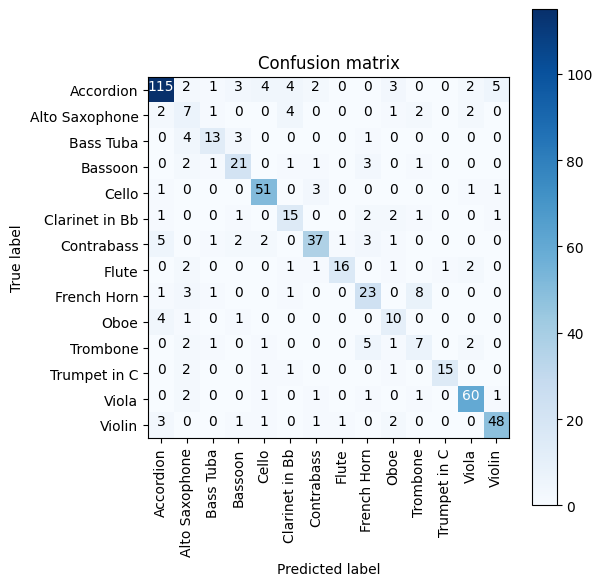


Result of Decision Tree Classifier of Mel-Spectrogram:

Best max_depth: 14 with validation accuracy = 0.7545
test accuracy = 0.774
precision     = 0.716
recall        = 0.698
F1-score      = 0.701
Confusion matrix


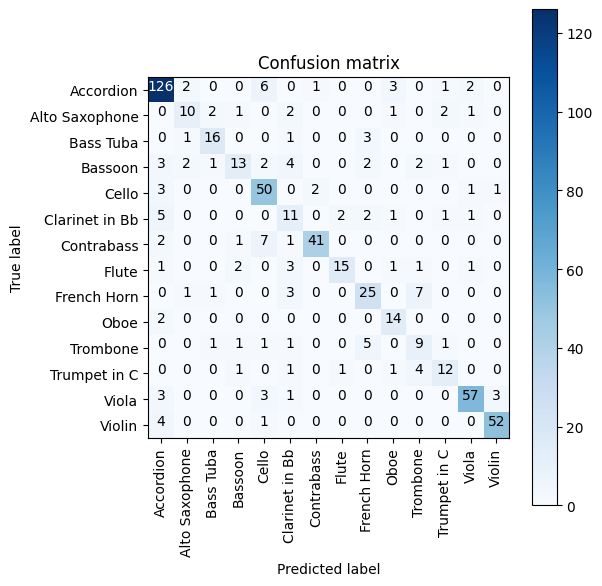


Result of Decision Tree Classifier of CQT:

Best max_depth: 19 with validation accuracy = 0.7781
test accuracy = 0.762
precision     = 0.73
recall        = 0.708
F1-score      = 0.715
Confusion matrix


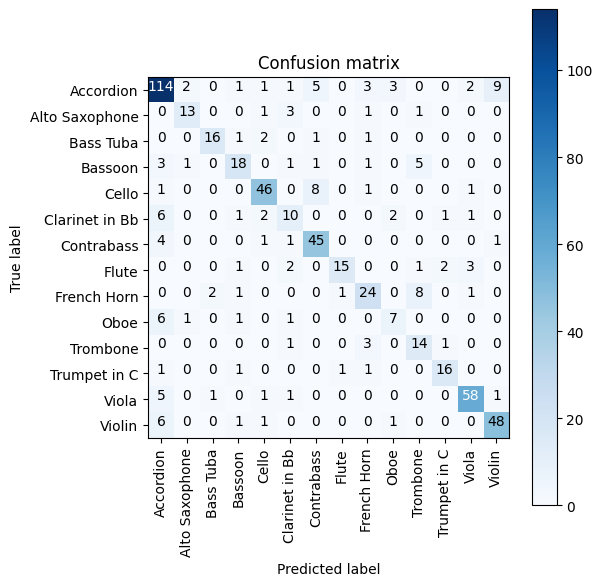

In [70]:
for feature in features:
    print('\n===================================================================================')
    print(f"Result of Decision Tree Classifier of {feature}:\n")
    print(f"Best max_depth: {results[feature]['best_depth']} with validation accuracy = {results[feature]['val_acc']:.4f}")
    print(f"test accuracy = {round(results[feature]['test_acc'], 3)}")
    print(f"precision     = {round(results[feature]['precision'], 3)}")
    print(f"recall        = {round(results[feature]['recall'], 3)}")
    print(f"F1-score      = {round(results[feature]['f1'], 3)}")
    plot_confusion_matrix(results[feature]['confusion_matrix'] , instrument_classes)

根據 confusion matrix 可以看到 French Horn 跟 Trombone 分辨錯誤的比率較高

#### 1.c.b.

In [25]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

In [26]:
spec_list = []
mel_list = []
cqt_list = []
instrument_list = []
# pitch_list = []

for track_id in tinysol_dataset.track_ids:

    track = tinysol_dataset.track(track_id)
    audio, sr = track.audio

    spec = librosa.amplitude_to_db(np.abs(librosa.stft(audio, n_fft=2048, hop_length=512)), ref=np.max)
    spec_list.append(spec)

    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=2048, n_mels=64, fmax=sr//2), ref=np.max)
    mel_list.append(mel)

    cqt = librosa.amplitude_to_db(np.abs(librosa.cqt(audio, sr=sr)), ref=np.max)
    cqt_list.append(cqt)

    instrument_list.append(track.instrument_full)
    # pitch_list.append(track.pitch)

# 每個音檔不同長度，所以圖的長也不同，這邊統一成128*128
def ImageResize(image_list, shape=(128, 128)):
    resized_list = []
    for image in image_list:
        resized = cv2.resize(spec, shape)
        resized_list.append(resized)
    return np.array(resized_list)

spec_array = ImageResize(spec_list)
mel_array = ImageResize(mel_list)
cqt_array = ImageResize(cqt_list)
instrument_array = np.array(instrument_list)
# pitch_array = np.array(pitch_list)

le = LabelEncoder()
instrument_array = le.fit_transform(instrument_array)
instrument_classes = le.classes_
# pitch_array = le.fit_transform(pitch_array)
# pitch_classes = le.classes_

In [ ]:
X = np.expand_dims(mel_array, axis=-1).astype("float32")
X = X / np.max(X, axis=(1,2,3), keepdims=True)  # normalize
instrument_onehot = tf.keras.utils.to_categorical(instrument_array) # one-hot

X_train, X_test, y_train, y_test = train_test_split(X, instrument_onehot, test_size=0.2, random_state=23)

model = Sequential([
    Conv2D(6, kernel_size=(5,5), activation='relu', input_shape=X.shape[1:]),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(16, kernel_size=(5,5), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(120, activation='relu'),
    Dense(84, activation='relu'),
    Dense(instrument_onehot.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true_labels, y_pred_labels)
recall = recall_score(y_true_labels, y_pred_labels, average='macro') #can try other ave method
precision = precision_score(y_true_labels, y_pred_labels, average='macro')
f1 = f1_score(y_true_labels, y_pred_labels, average='macro')
cm = confusion_matrix(y_true_labels, y_pred_labels)


results={}
feature = 'mel'
results[feature] = {
    'test_acc': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'confusion_matrix': cm
}

Epoch 1/20
59/59 [==============================] - 4s 54ms/step - loss: 3.2995 - accuracy: 0.1937 - val_loss: 2.4431 - val_accuracy: 0.2468
Epoch 2/20
59/59 [==============================] - 3s 51ms/step - loss: 2.4525 - accuracy: 0.2323 - val_loss: 2.4574 - val_accuracy: 0.2468
Epoch 3/20
59/59 [==============================] - 3s 51ms/step - loss: 2.4495 - accuracy: 0.2323 - val_loss: 2.4357 - val_accuracy: 0.2468
Epoch 4/20
59/59 [==============================] - 3s 51ms/step - loss: 2.4321 - accuracy: 0.2323 - val_loss: 2.4277 - val_accuracy: 0.2468
Epoch 5/20
59/59 [==============================] - 3s 51ms/step - loss: 2.4286 - accuracy: 0.2323 - val_loss: 2.4299 - val_accuracy: 0.2468
Epoch 6/20
59/59 [==============================] - 3s 51ms/step - loss: 2.4307 - accuracy: 0.2323 - val_loss: 2.4224 - val_accuracy: 0.2468
Epoch 7/20
59/59 [==============================] - 3s 50ms/step - loss: 2.4259 - accuracy: 0.2323 - val_loss: 2.4629 - val_accuracy: 0.2468
Epoch 8/20
59

c:\Users\WilsonW\anaconda3\envs\mir_env\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


NameError: name 'best_depth' is not defined

In [ ]:
print('\n===================================================================================')
print(f"Result of Decision Tree Classifier of {feature}:\n")
print(f"Best max_depth: {results[feature]['best_depth']} with validation accuracy = {results[feature]['val_acc']:.4f}")
print(f"test accuracy = {round(results[feature]['test_acc'], 3)}")
print(f"precision     = {round(results[feature]['precision'], 3)}")
print(f"recall        = {round(results[feature]['recall'], 3)}")
print(f"F1-score      = {round(results[feature]['f1'], 3)}")
plot_confusion_matrix(results[feature]['confusion_matrix'] , instrument_classes)